# Training with Combined Real and Synthetic Datasets

This notebook demonstrates how to train a model using both real and synthetic datasets, with a specified ratio of synthetic to real samples in the training set. Validation and test are performed only on real data.

In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from RQ1_synth_data.train_real_synth import run

/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-81


2025-07-10 20:26:23 INFO     Logs will be written to output/test synth/20250710_202623/log_training.txt
2025-07-10 20:27:15 WARNING  Requested ratio 1 could not be satisfied. Using all 256 synthetic samples for 310 real samples. Actual ratio: 0.8258064516129032
2025-07-10 20:27:15 INFO     Training set: 310 real + 256 synthetic (ratio used: 0.8258064516129032)
2025-07-10 20:27:15 INFO     Validation set: 104 real only
2025-07-10 20:27:15 INFO     Test set: 104 real only
2025-07-10 20:27:15 INFO     Will start training from scratch
2025-07-10 20:27:15 WARNING  Requested ratio 1 could not be satisfied. Using all 256 synthetic samples for 310 real samples. Actual ratio: 0.8258064516129032
2025-07-10 20:27:15 INFO     Training set: 310 real + 256 synthetic (ratio used: 0.8258064516129032)
2025-07-10 20:27:15 INFO     Validation set: 104 real only
2025-07-10 20:27:15 INFO     Test set: 104 real only
2025-07-10 20:27:15 INFO     Will start training from scratch
[neptune] [warning] NeptuneUns

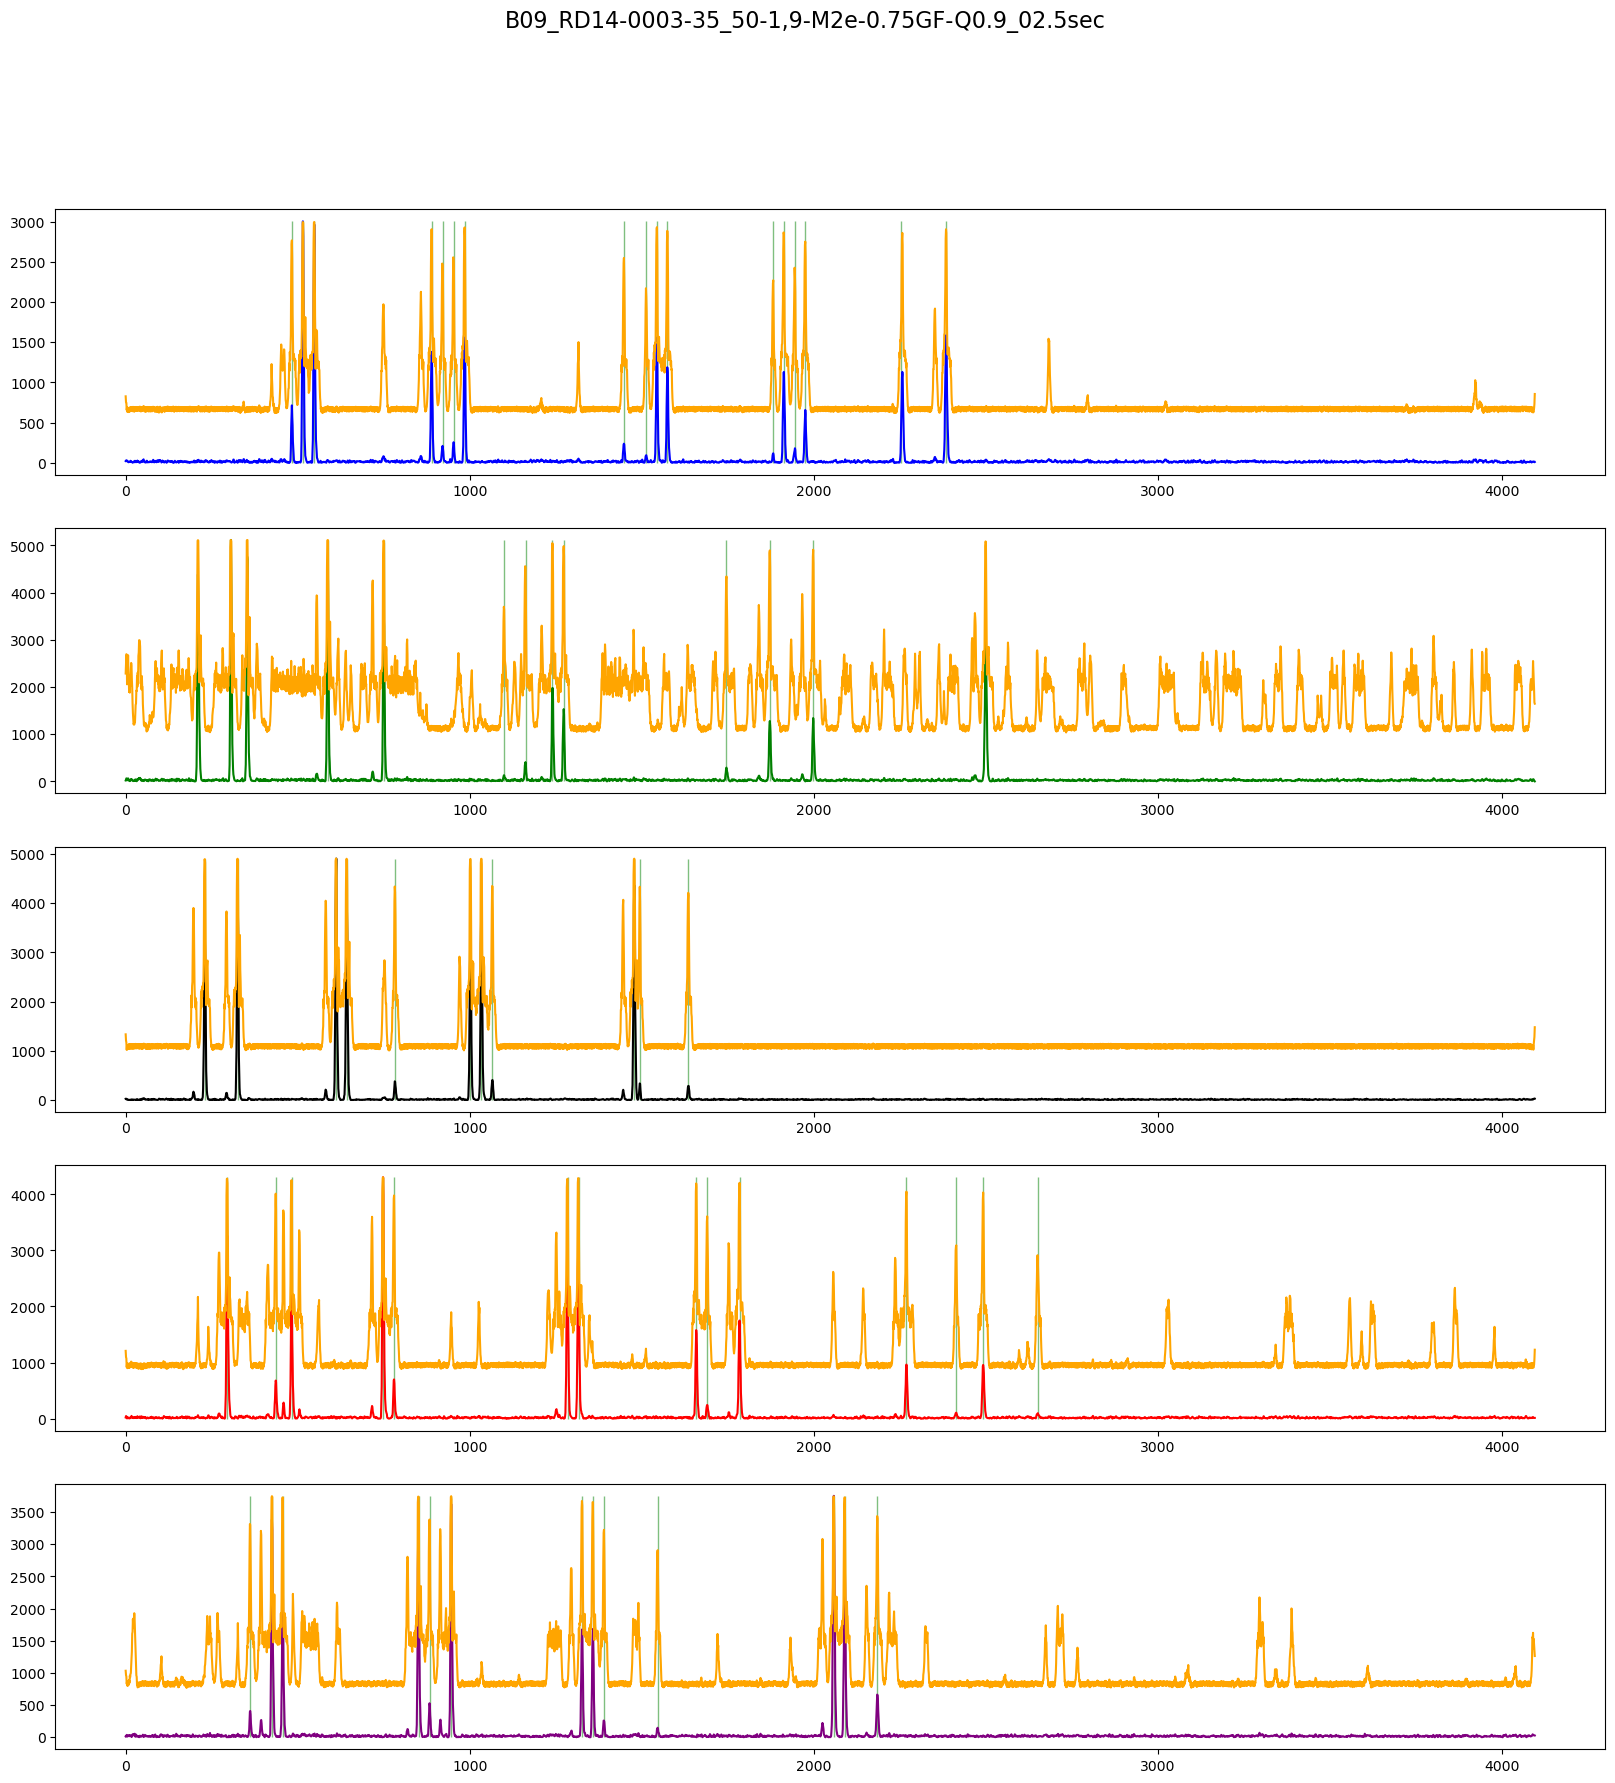

2025-07-10 20:27:45 INFO     Saved best model with loss 0.978192 at epoch 1.
2025-07-10 20:27:45 INFO     Epoch 1/200: scheduler decreased learning rate to 0.01
Epoch 2/200: 100%|██████████| 17/17 [00:22<00:00,  1.31s/it, training_loss=0.957]
2025-07-10 20:28:07 INFO     Epoch 2/200 - Training binaryaccuracy: 0.976544
2025-07-10 20:28:07 INFO     Epoch 2/200 - Training loss: 0.956936
Epoch 2/200: 100%|██████████| 17/17 [00:22<00:00,  1.31s/it, training_loss=0.957]
2025-07-10 20:28:07 INFO     Epoch 2/200 - Training binaryaccuracy: 0.976544
2025-07-10 20:28:07 INFO     Epoch 2/200 - Training loss: 0.956936
Epoch 2/200: 4it [00:01,  2.58it/s, validation_loss=0.919]                       
2025-07-10 20:28:11 INFO     Epoch 2/200 - Validation metric (BinaryAccuracy()): 0.988117 | Validation loss: 0.918671
2025-07-10 20:28:11 INFO     Epoch 2/200 - Validation binaryaccuracy: 0.990464
Epoch 2/200: 4it [00:01,  2.58it/s, validation_loss=0.919]                       
2025-07-10 20:28:11 INFO  

In [ ]:
run(
    real_data_config="provedit_data.yaml",
    synth_data_config="synth_data.yaml",
    model_config="unet_amar.yaml",
    training_config="training_amar.yaml",
    ratio=1
)

## Notes and Recommendations

- Ensure that your `synthetic_data.yaml` and `provedit_data.yaml` are correctly configured for their respective datasets.
- The `run` function expects the new signature: `run(real_data_config, synth_data_config, model_config, training_config, ratio, checkpoint_dir=None)`.
- The synthetic dataset should be large enough to satisfy the requested ratio; otherwise, all available synthetic samples will be used and the actual ratio will be logged.
- If you want to change the ratio, simply modify the `ratio` variable above.
- Make sure your `load_dataset` function in `config_io.py` can handle both real and synthetic dataset configs.
- If you want to use Neptune logging, ensure your Neptune credentials are set and `log_neptune` is enabled in your training config.

In [ ]:
from config_io import load_model

unet_model = load_model("config/models/unet_amar_1.yaml")
unet_model.load("output/real_data-best_unet-use_scheduler-delta_1/checkpoint/")

# Set config files and ratio
real_data_config = "provedit_data.yaml"  # path to your real data config
test_data_config = "synthetic_data.yaml"  # path to your synthetic data config
model_config = "unet_amar.yaml"
training_config = "training_amar.yaml"
ratio = 100  # Number of synthetic samples per real sample in the training set

run(
    real_data_config=real_data_config,
    synth_data_config=test_data_config,
    model_config=model_config,
    training_config=training_config,
    ratio=ratio,
)

FileNotFoundError: [Errno 2] No such file or directory: 'config/models/config/models/unet_amar_1.yaml'

In [ ]:
from DNAnet.data.data_models import Panel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.parsing.file_parsing import find_files_by_suffix
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard


from typing import List
from pathlib import Path

gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"

panel = Panel(gf_panel_path)
hid_files = find_files_by_suffix(hid_files_path, ".hid")
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()

images = CustomHIDDataset(
    root_path=hid_files_path,
    panel_path=gf_panel_path,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation on

In [ ]:
predictions = unet_model.predict_batch(images)

2025-06-27 17:26:23 INFO     Calling alleles from predicted segmentation...
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:

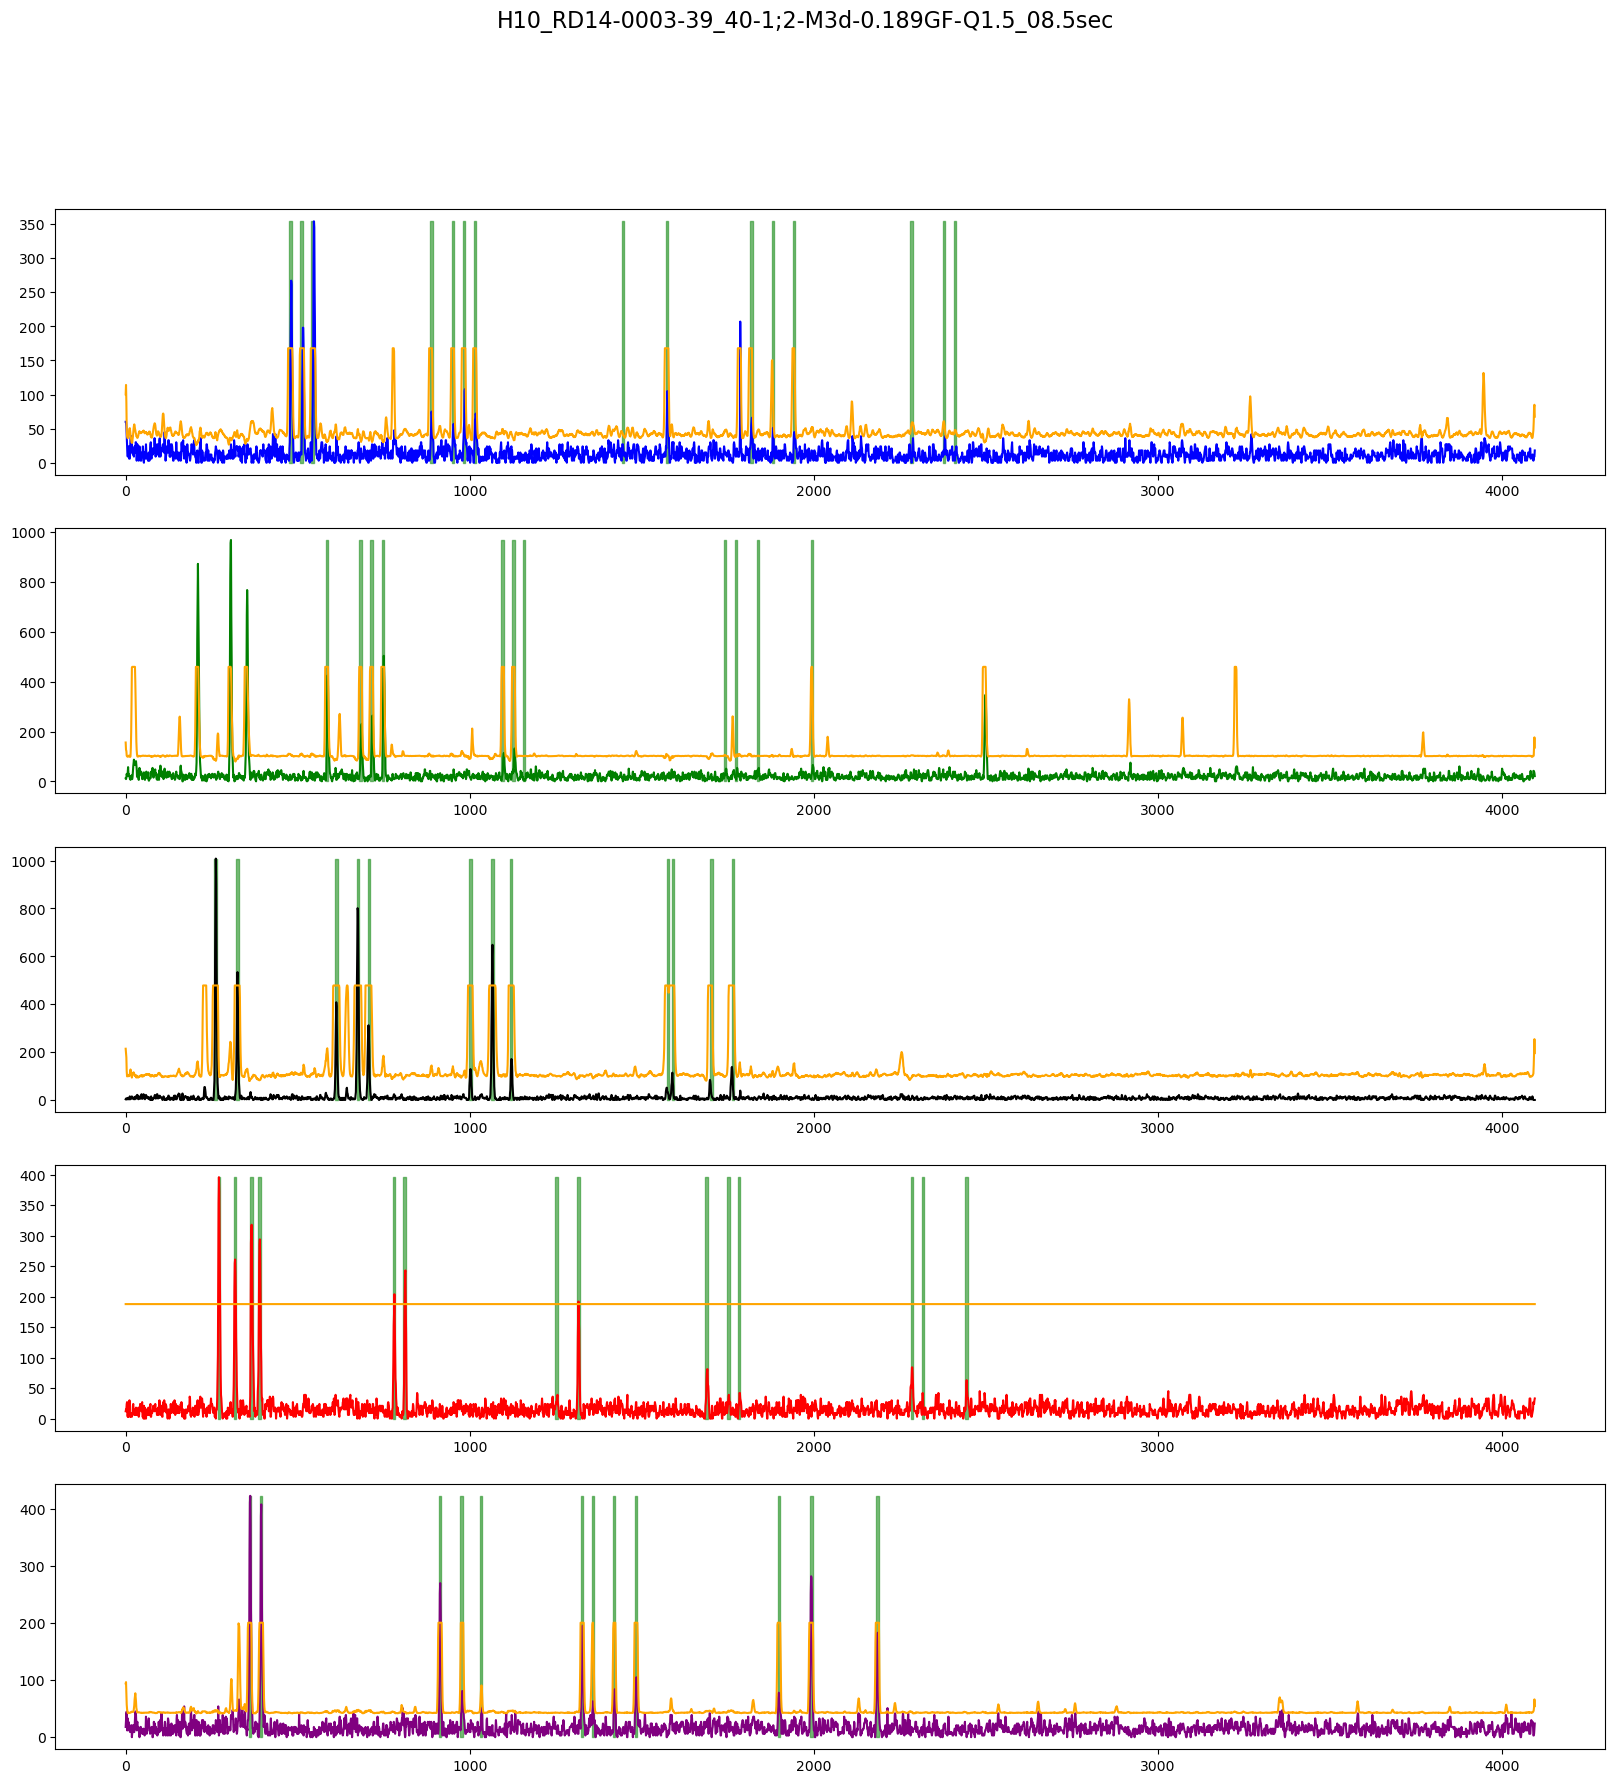

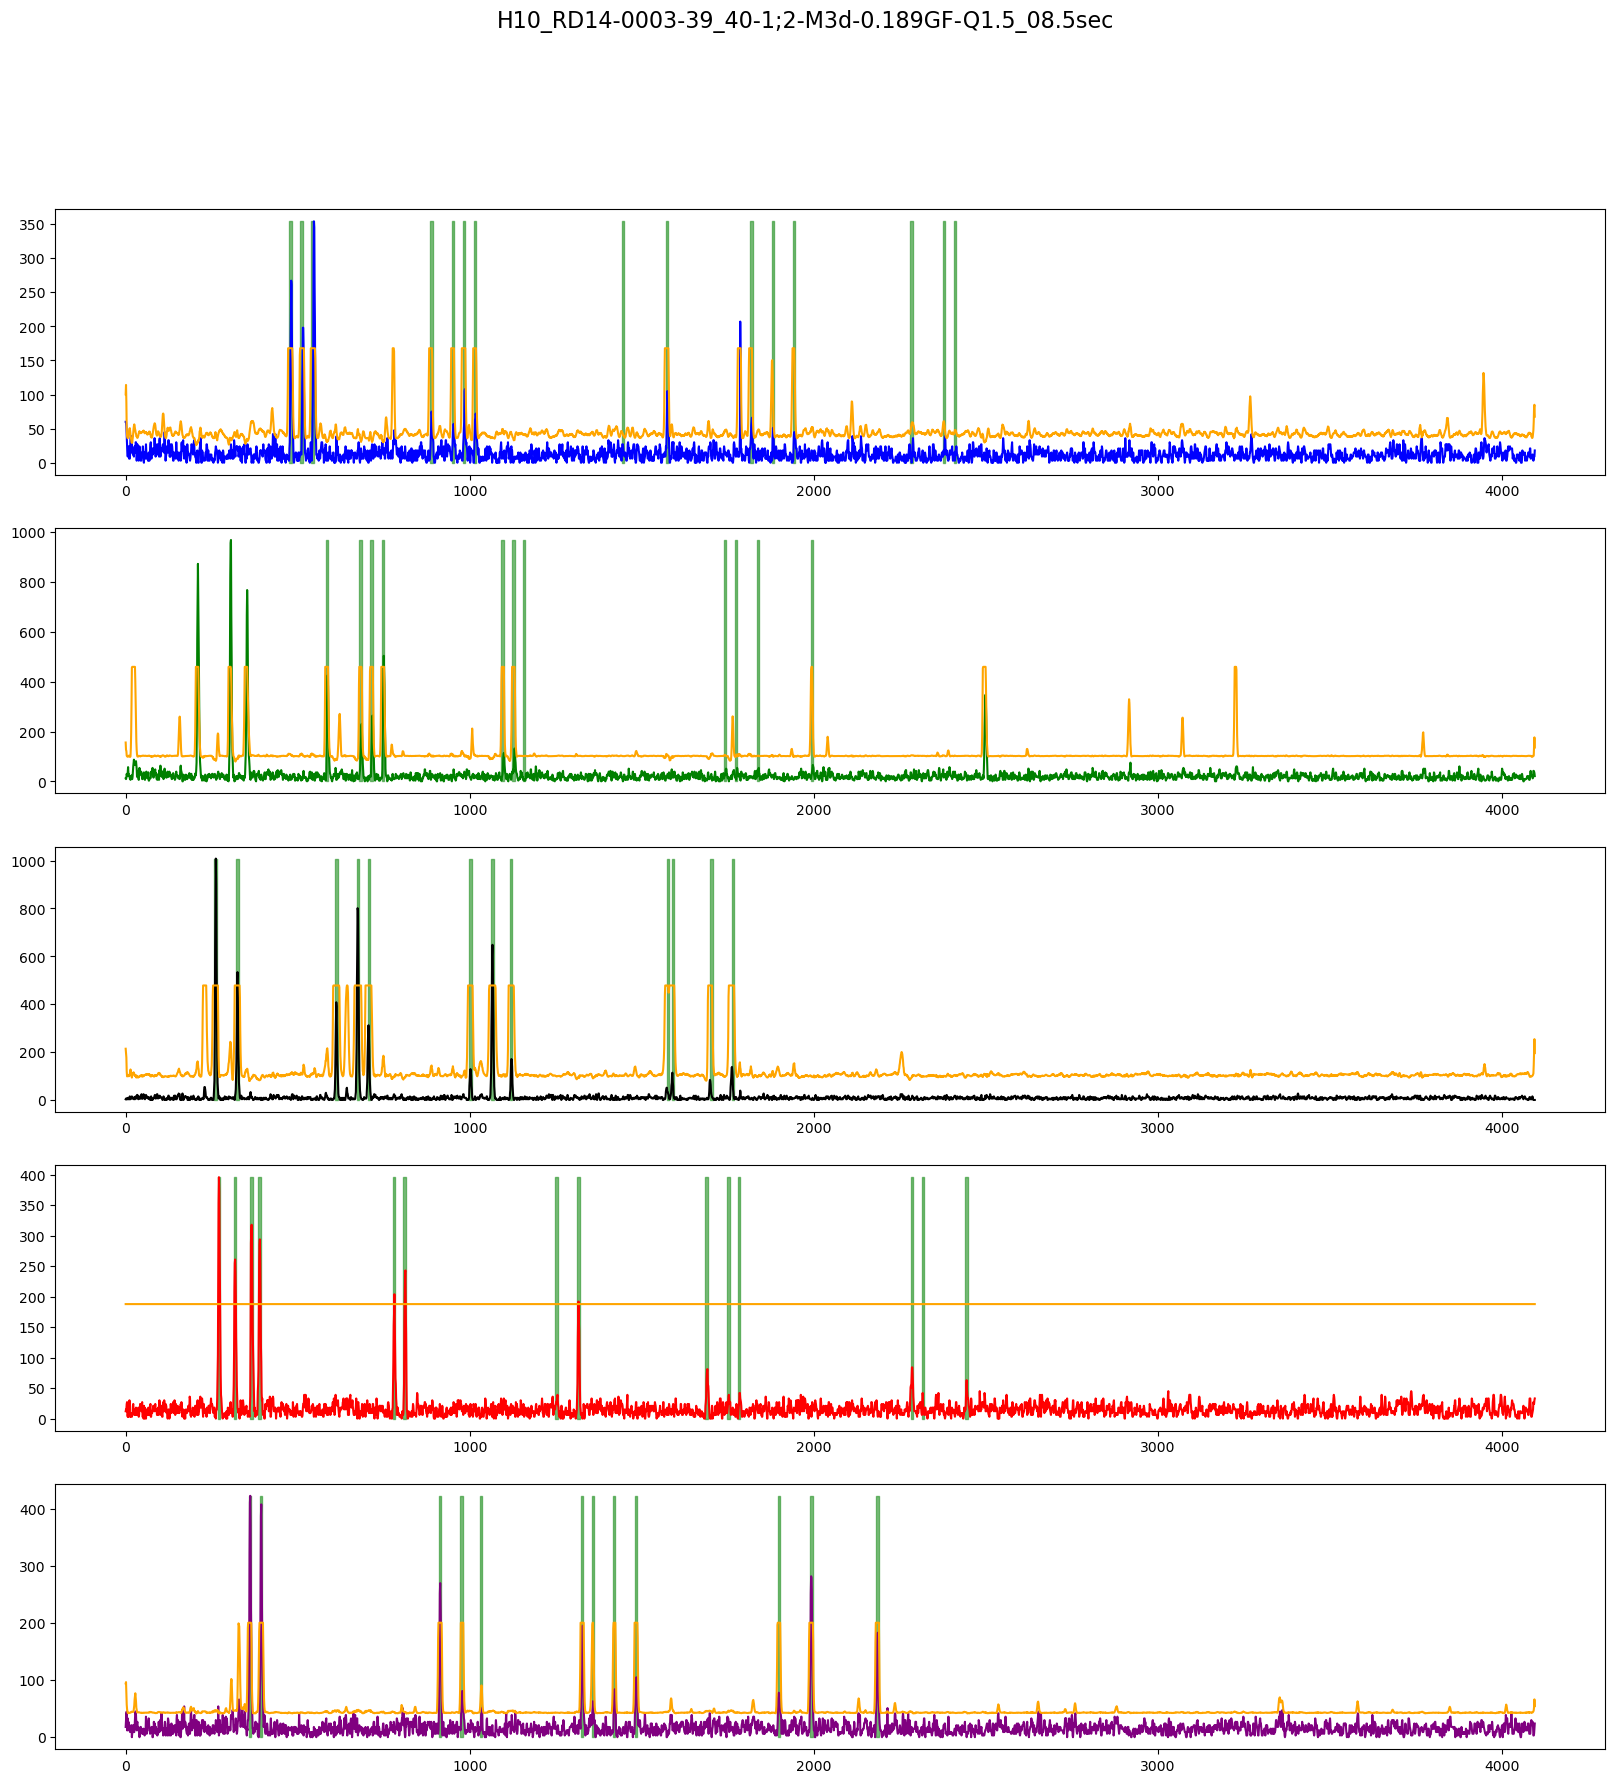

In [ ]:
from DNAnet.evaluation.visualizations import plot_profile


plot_profile(images[:1], predictions[:1], prediction_as_mask=False)

In [ ]:
best_unet_model = load_model("config/models/unet.yaml")
best_unet_model.load("resources/model/current_best_unet/")

In [ ]:
best_predictions = best_unet_model.predict_batch(images[:1])

2025-06-27 17:26:35 INFO     Calling alleles from predicted segmentation...


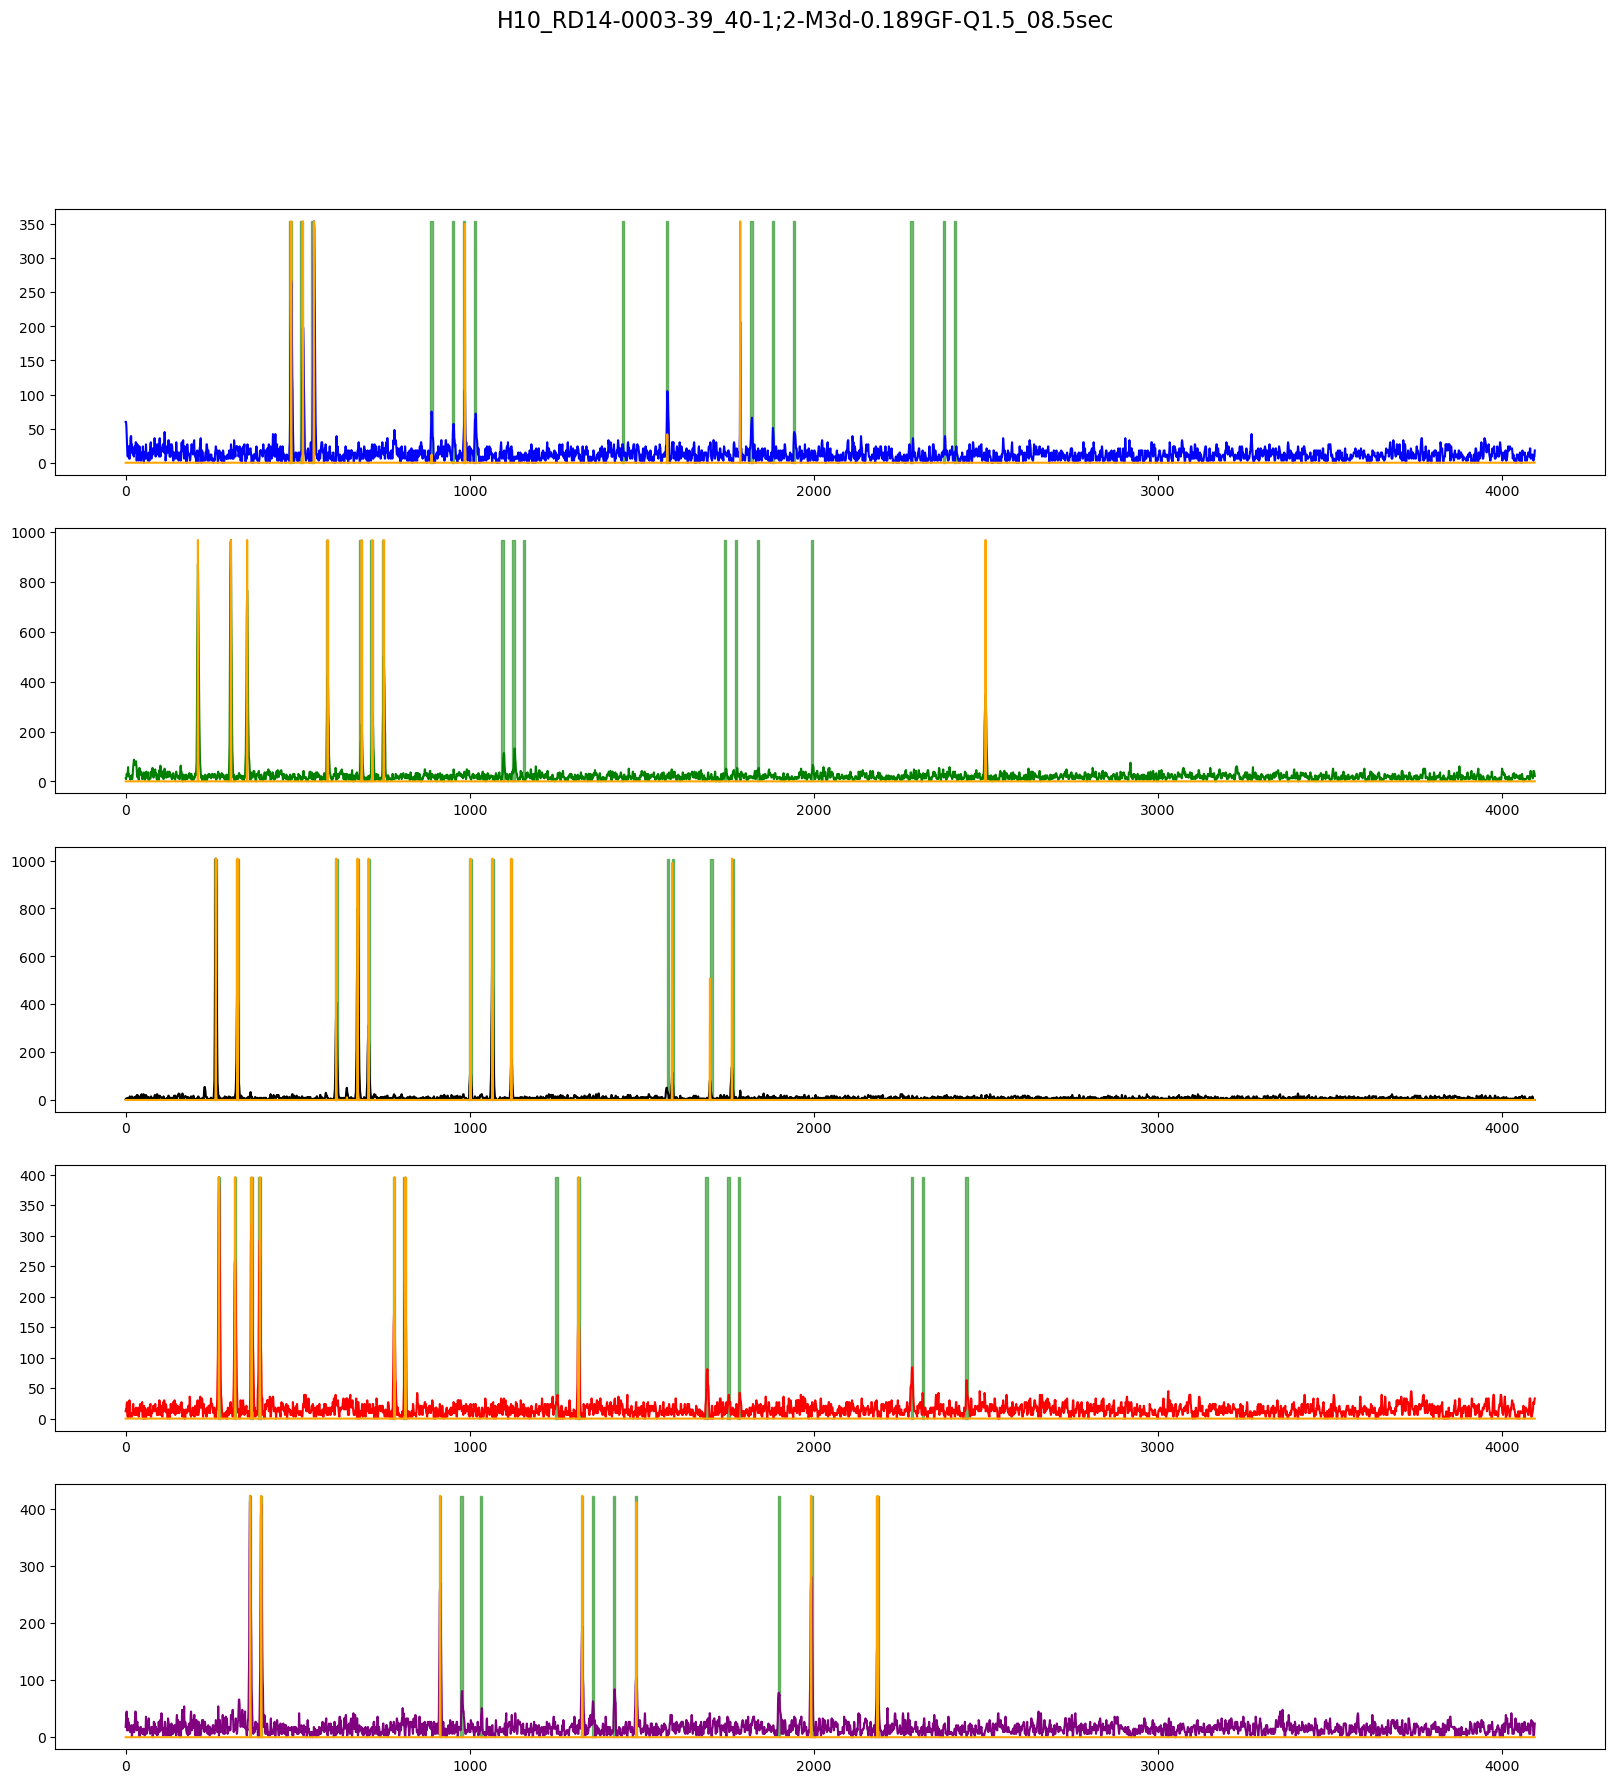

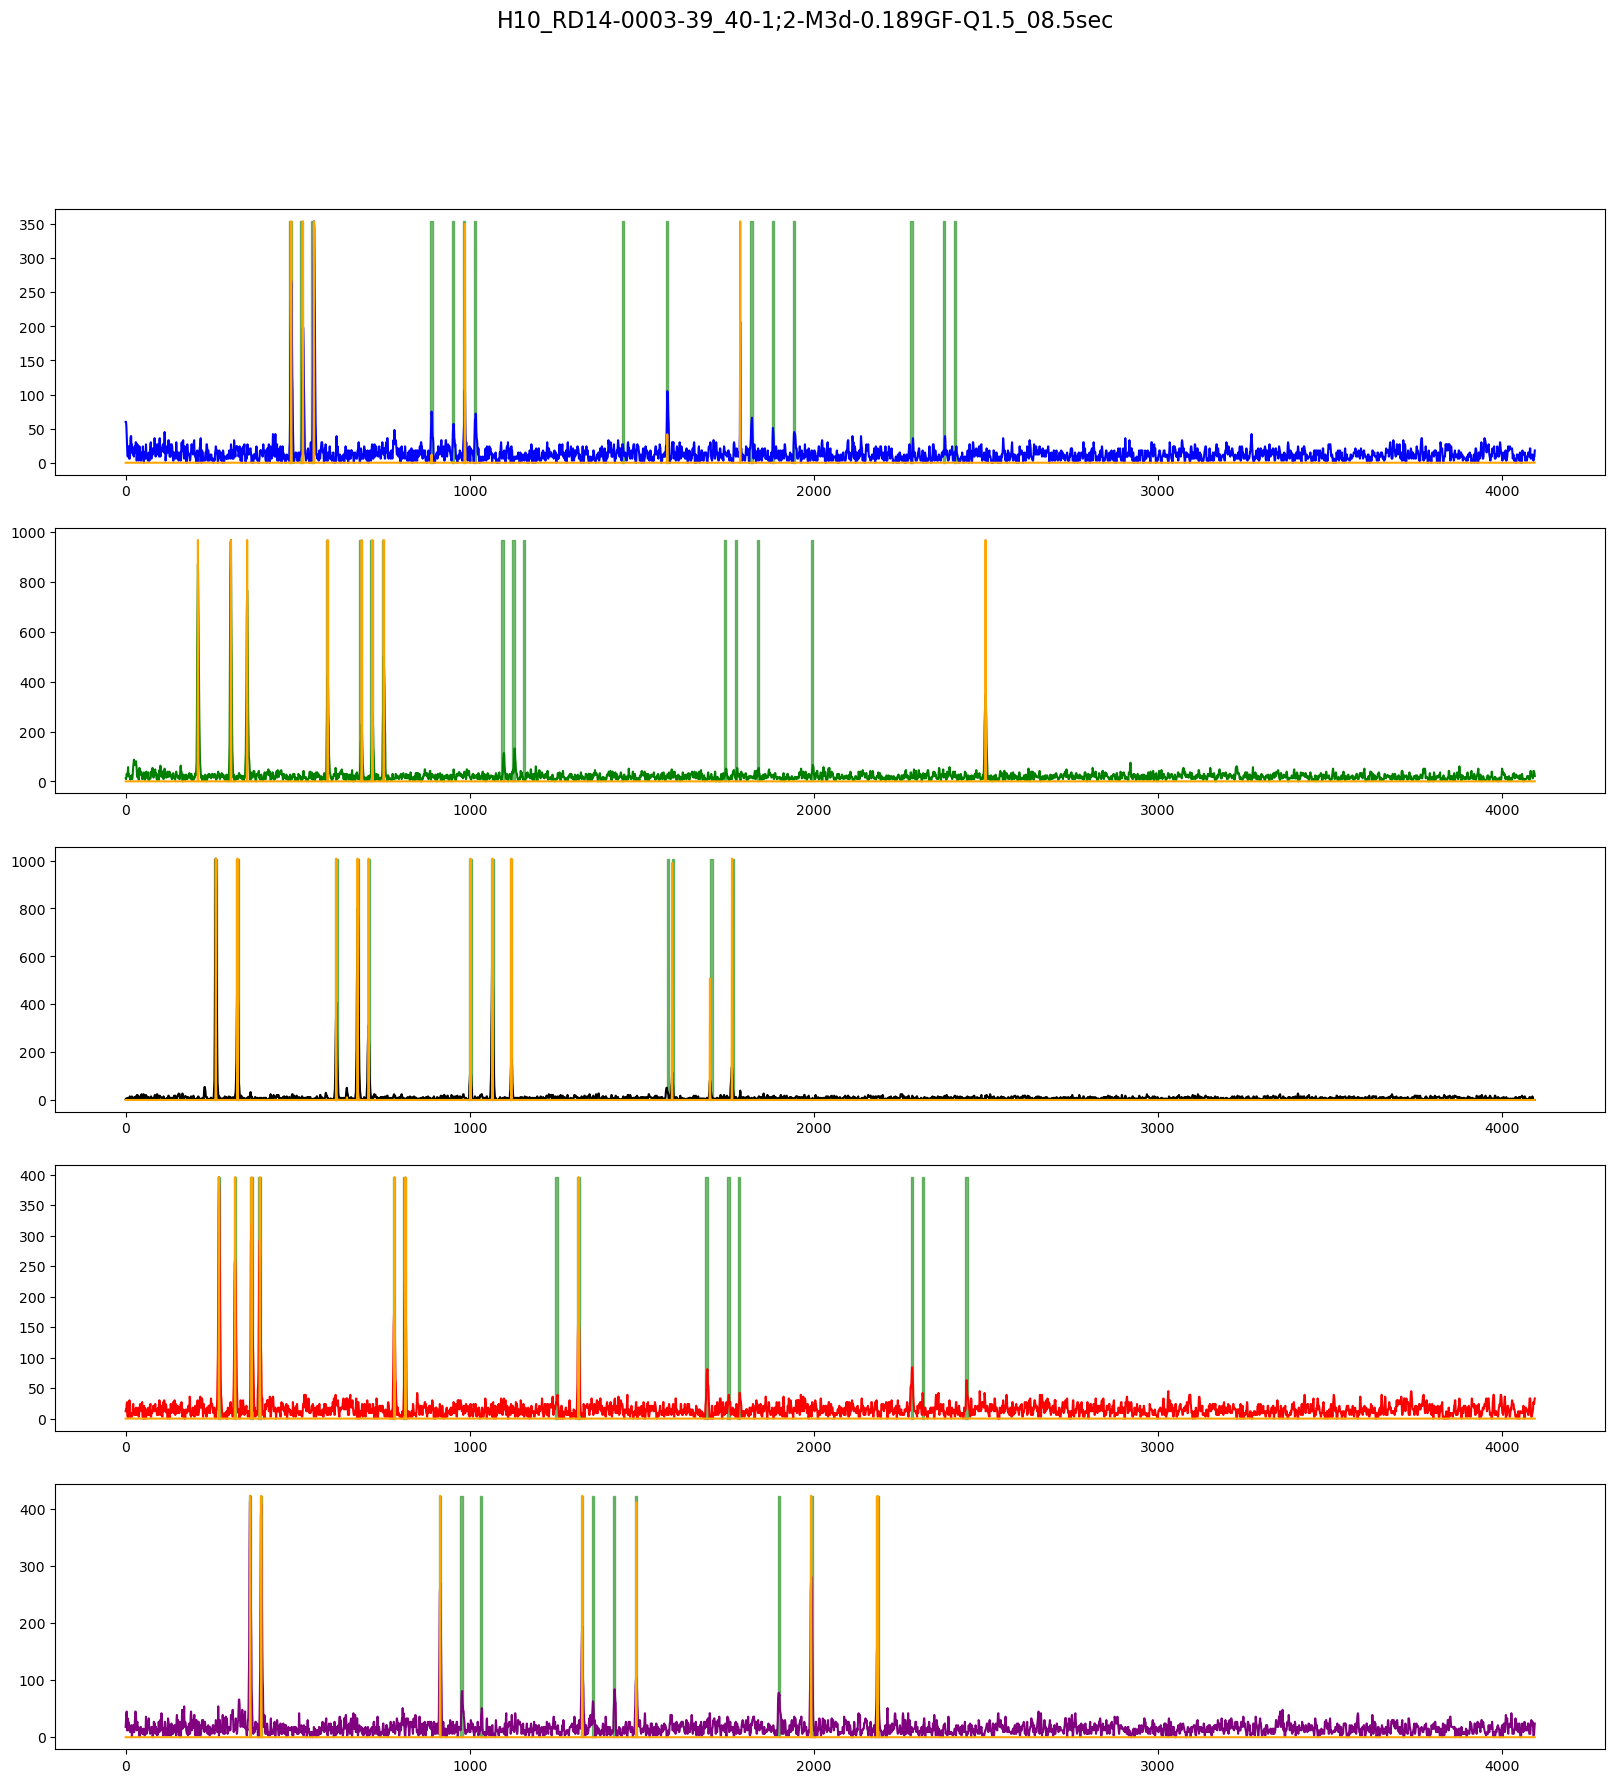

In [ ]:
plot_profile(images[:1], best_predictions[:1], prediction_as_mask=False)